# INAR (integer counts)

INAR — INteger-valued AutoRegression — generates *count* series: non-negative integers with autocorrelation, for demand, arrivals, and case counts where a Gaussian model makes no sense. It carries dependence forward through binomial thinning rather than a linear lag, so the output stays integer-valued.

::: {.callout-note}
## The model

$$X_t = \alpha_1 \circ X_{t-1} + \dots + \alpha_p \circ X_{t-p} + \varepsilon_t, \qquad \alpha \circ X = \sum_{i=1}^{X} \mathrm{Bernoulli}(\alpha)$$

Each step keeps a binomially-thinned fraction of the previous count and adds a fresh integer innovation. The thinning probability sets the persistence; the innovation distribution (`poisson` or `negative_binomial`) sets the marginal spread — negative binomial for overdispersion.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import INARGenerator

## 1. INAR(1) with Poisson innovations

A basic count process: each value depends on a thinned version of the previous value plus a Poisson-distributed innovation.

In [ ]:
poisson_gen = INARGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    p=1,
    alpha=[0.5],
    innovation_type="poisson",
    innovation_mean=3.0,
    seed=42,
)
poisson_df = poisson_gen.generate(n_series=1)

print(f"Generated {len(poisson_df)} count-valued observations")
print(f"Statistics: Mean={poisson_df['y'].mean():.4f}, Std={poisson_df['y'].std():.4f}")
poisson_df.head(10)

Generated 200 count-valued observations
Statistics: Mean=5.9300, Std=2.4092


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,8.0
"""0""",2000-01-02 00:00:00,11.0
"""0""",2000-01-03 00:00:00,7.0
"""0""",2000-01-04 00:00:00,5.0
"""0""",2000-01-05 00:00:00,2.0
"""0""",2000-01-06 00:00:00,5.0
"""0""",2000-01-07 00:00:00,6.0
"""0""",2000-01-08 00:00:00,3.0
"""0""",2000-01-09 00:00:00,5.0


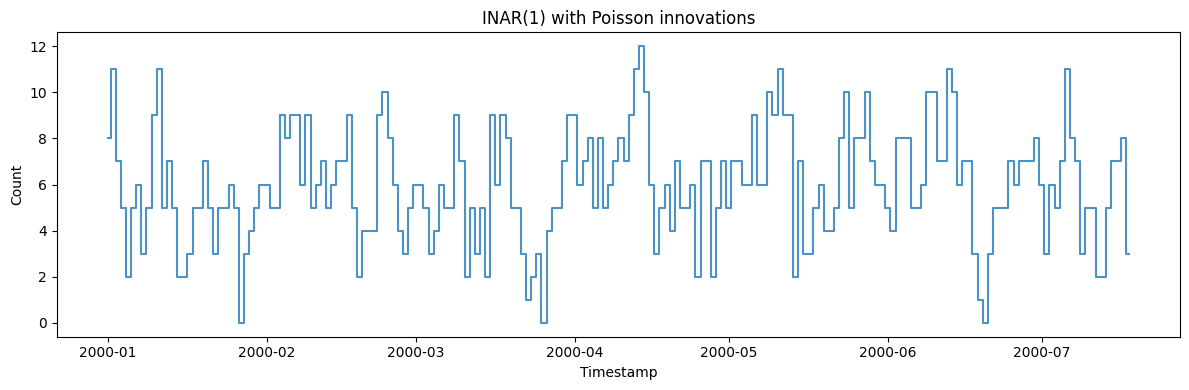

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.step(poisson_df["ds"].to_list(), poisson_df["y"].to_list(), where="mid", alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Count")
ax.set_title("INAR(1) with Poisson innovations")
plt.tight_layout()
plt.show()

## 2. INAR(1) with negative binomial innovations

Negative binomial innovations produce overdispersed counts (variance > mean), common in real-world event data.

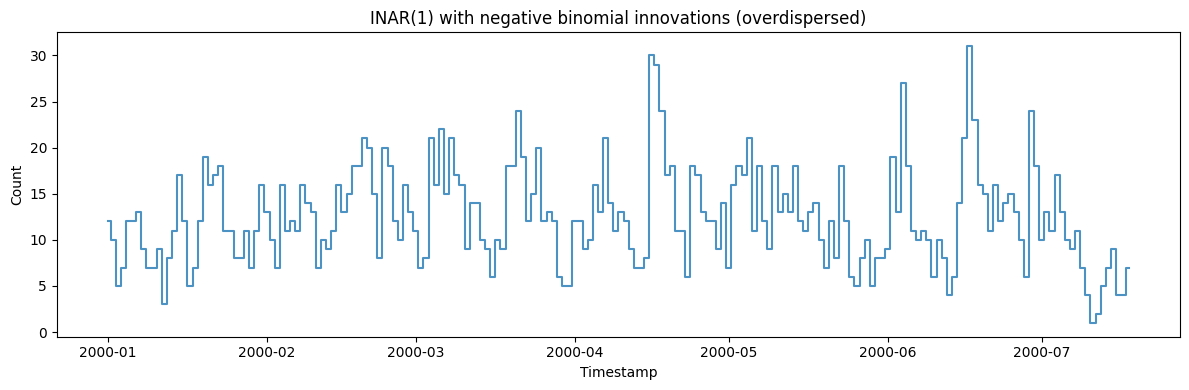

In [ ]:
nb_gen = INARGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    p=1,
    alpha=[0.6],
    innovation_type="negative_binomial",
    innovation_mean=5.0,
    innovation_dispersion=2.0,
    seed=42,
)
nb_df = nb_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.step(nb_df["ds"].to_list(), nb_df["y"].to_list(), where="mid", alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Count")
ax.set_title("INAR(1) with negative binomial innovations (overdispersed)")
plt.tight_layout()
plt.show()

## 3. INAR(2) - higher order dependence

INAR(2) models have memory over two lags, producing smoother count dynamics.

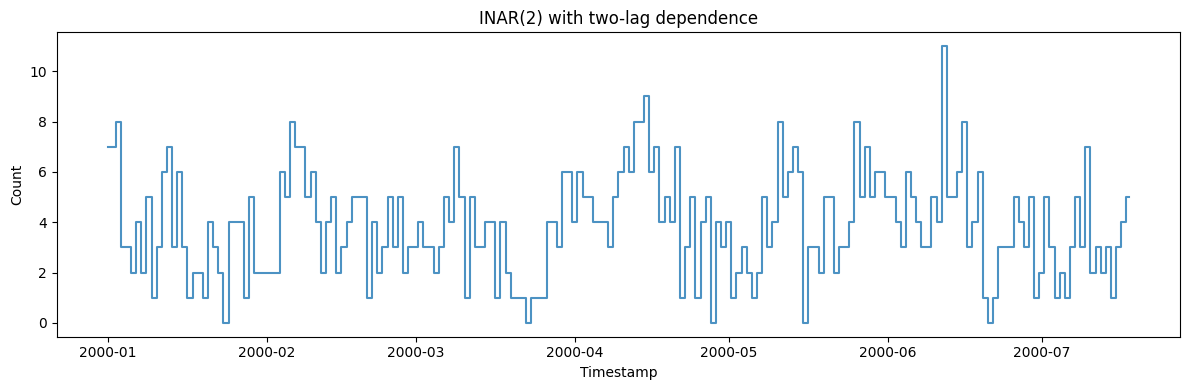

In [ ]:
inar2_gen = INARGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    p=2,
    alpha=[0.3, 0.2],
    innovation_type="poisson",
    innovation_mean=2.0,
    seed=42,
)
inar2_df = inar2_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.step(inar2_df["ds"].to_list(), inar2_df["y"].to_list(), where="mid", alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Count")
ax.set_title("INAR(2) with two-lag dependence")
plt.tight_layout()
plt.show()

## 4. Multiple series

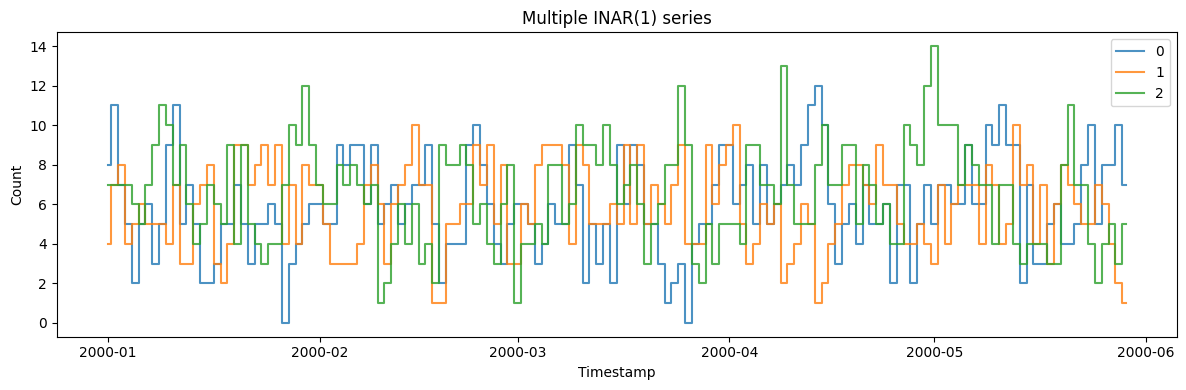

In [ ]:
multi_gen = INARGenerator(engine="polars", 
    min_length=150, max_length=150, freq="D",
    p=1, alpha=[0.5], innovation_mean=3.0, seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.step(series["ds"].to_list(), series["y"].to_list(), where="mid", label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Count")
ax.set_title("Multiple INAR(1) series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Intermittent demand](../domain/intermittent_demand) — sparse counts with many zeros.
- [Poisson process](../stochastic/poisson_process) — event arrivals in continuous time.

Innovation and thinning parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::